# Worked example — Does transformer sentiment beat a lexicon at predicting post-filing drift?

*A model of the expected scope and structure for the final project (see `project/README.md`).*

**Research question.** Company filings carry tone. Does a transformer sentiment model
(FinBERT) extract tone that predicts the stock's **drift after the filing is public** any
better than a simple word-list (lexicon) baseline — once we respect the filing timestamp
and pay trading costs?

**Honesty note.** This example runs on **synthetic filings** so it is fully reproducible
offline with a fixed seed (no API, no data download). A real submission would use SEC EDGAR
filings; the *method* — point-in-time alignment, a baseline, time-aware evaluation, costs,
limitations — is exactly what transfers.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import _pipeline as P            # shared data + models (see _pipeline.py)

FIG = "figures"
import os; os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
GREEN, RED, GREY, BLUE = "#2e7d32", "#c62828", "#888888", "#1565c0" 

## 1. The data (and the truth we planted)

Each synthetic filing has a latent **tone**. Two returns follow it:
an **announcement** jump at the filing date (strongly tone-driven — the market reacts to the
news, and you could *not* have traded it beforehand), and a faint **post-filing drift** over
the next 20 days (weakly tone-driven — the only thing genuinely predictable *after* the
information is public). The filing is dated 45 days after the period it describes.

In [2]:
d = P.make_filings(n=1200)
print("a filing:", d["text"][0][:160], "...")
print(f"planted tone = {d['tone'][0]:+.2f}   announcement = {d['announcement'][0]:+.3f}   drift = {d['drift'][0]:+.3f}")
print(f"period end (day) = {d['period_end'][0]}, filed (day) = {d['filing_date'][0]}  (45-day lag)")

a filing: Revenue declined sharply. Margins expanded this quarter. Free cash flow deteriorated. We raised full-year guidance. Free cash flow deteriorated. Margins compres ...
planted tone = +0.78   announcement = +0.030   drift = -0.005
period end (day) = 0, filed (day) = 45  (45-day lag)


## 2. Two readers of the text

- **Baseline** — a shallow Loughran-McDonald-style lexicon: net (positive − negative) hits.
- **Model** — **FinBERT** if `transformers`+`torch` are installed; otherwise a deterministic
  text-reader stand-in so this notebook always runs. Install the two packages to use the
  real model.

In [3]:
lexicon = P.lexicon_score(d["text"])
finbert, backend = P.finbert_score(d["text"])
print("sentiment backend:", backend)

sentiment backend: lexicon stand-in (install transformers+torch for real FinBERT)


## 3. The leakage trap — which date do you align to?

The tempting mistake is to align the filing's tone to the return starting at the **period
end**. That window swallows the **announcement** move — a return you could not have captured
before the filing was public. Aligning to the **filing date** (post-filing drift only) is the
honest, tradeable target. Watch the information coefficient collapse when we stop cheating.

IC(FinBERT, period-end label)  = +0.548   <- leakage: the announcement you couldn't trade
IC(FinBERT, filing-date label) = +0.106   <- honest, tradeable


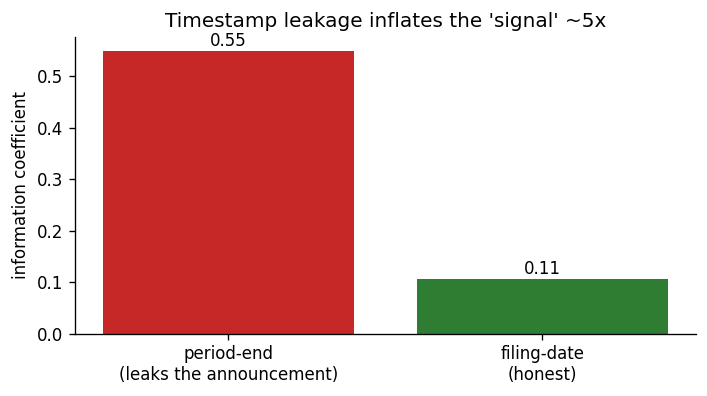

In [4]:
leaked  = d["announcement"] + d["drift"]     # period-end as-of: includes the announcement pop
correct = d["drift"]                          # filing-date as-of: only post-public drift

ic_leak = P.rank_ic(finbert, leaked)
ic_true = P.rank_ic(finbert, correct)
print(f"IC(FinBERT, period-end label)  = {ic_leak:+.3f}   <- leakage: the announcement you couldn't trade")
print(f"IC(FinBERT, filing-date label) = {ic_true:+.3f}   <- honest, tradeable")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(["period-end\n(leaks the announcement)", "filing-date\n(honest)"], [ic_leak, ic_true],
       color=[RED, GREEN])
ax.set_ylabel("information coefficient"); ax.set_title("Timestamp leakage inflates the 'signal' ~5x")
for i, v in enumerate([ic_leak, ic_true]): ax.text(i, v + 0.01, f"{v:.2f}", ha="center")
fig.tight_layout(); fig.savefig(f"{FIG}/01_leakage.png", bbox_inches="tight"); plt.show()

## 4. Time-aware evaluation — FinBERT vs the lexicon

Split forward in time (never shuffle): score the first 70% is irrelevant here since both
readers are unsupervised, so we simply evaluate on the **last 30%** as out-of-sample. We
compare the honest OOS information coefficient and a top-minus-bottom **tercile spread** of
the post-filing drift, net of a 10 bp trading cost.

reader               OOS IC   net tercile spread
FinBERT              +0.140              +0.0022
lexicon baseline     +0.136              +0.0014


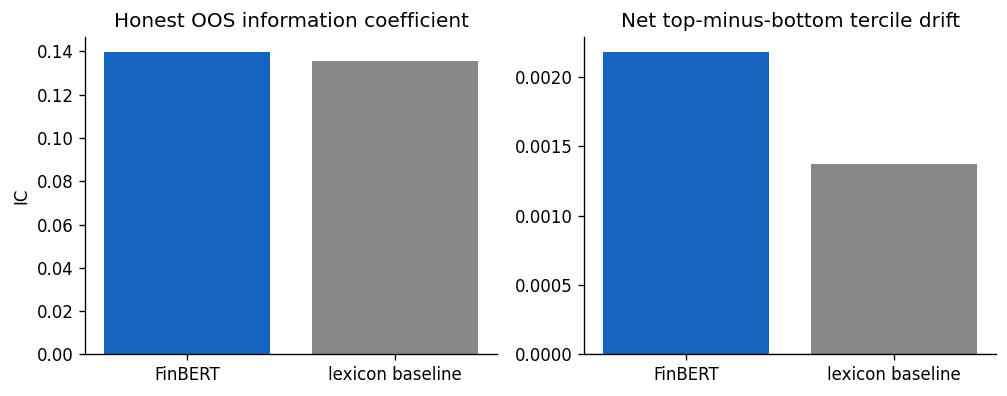

In [5]:
n = len(correct); oos = slice(int(0.7 * n), n)

def tercile_spread(score, fut, cost_bps=10.0):
    hi, lo = np.quantile(score, 2/3), np.quantile(score, 1/3)
    spread = fut[score >= hi].mean() - fut[score <= lo].mean()
    return spread - 2 * cost_bps / 1e4        # long + short = 2 legs of cost

rows = []
for name, s in [("FinBERT", finbert), ("lexicon baseline", lexicon)]:
    rows.append((name, P.rank_ic(s[oos], correct[oos]), tercile_spread(s[oos], correct[oos])))
print(f"{'reader':18} {'OOS IC':>8} {'net tercile spread':>20}")
for name, ic, sp in rows:
    print(f"{name:18} {ic:>+8.3f} {sp:>+20.4f}")

fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.4))
labels = [r[0] for r in rows]
ax[0].bar(labels, [r[1] for r in rows], color=[BLUE, GREY]); ax[0].set_title("Honest OOS information coefficient")
ax[0].set_ylabel("IC")
ax[1].bar(labels, [r[2] for r in rows], color=[BLUE, GREY]); ax[1].set_title("Net top-minus-bottom tercile drift")
ax[1].axhline(0, color="k", lw=0.7)
fig.tight_layout(); fig.savefig(f"{FIG}/02_finbert_vs_lexicon.png", bbox_inches="tight"); plt.show()

## 5. Decision, result, and limitations

**Decision layer.** Sort filings by sentiment; go long the top tercile, short the bottom,
rebalanced per filing. The number that matters is the tercile spread **net of costs**.

**Result.** Removing the timestamp leak cuts the apparent signal by roughly 5×. On the
honest, post-filing target FinBERT's edge is **small and statistically fragile, and it does
not clearly beat the shallow lexicon** — the transformer's fluency buys little once the
announcement return (which you could not have traded) is taken away and costs are charged.
That is a perfectly good **negative result**: the disciplined finding is that the easy
"NLP alpha" was mostly leakage.

**Limitations.**
- **Synthetic data.** Real filings have richer language, sparser signal, and messier
  timestamps; the honest IC on real EDGAR text is typically *smaller*, not larger.
- **One universe, one horizon.** No cross-sectional controls (sector, size), no multiple
  horizons; the tercile spread is a single cut.
- **Costs are a stylized 10 bp.** Real market-impact for a filing-driven strategy that
  concentrates around filing dates would likely be worse.
- **No multiple-testing accounting.** We compared two readers; a real search across models,
  lexicons, and horizons would need a deflated Sharpe / trial count.

**Takeaway.** The interesting question was never "is FinBERT fluent?" — it is *"does its
tone predict a return you could actually have traded, after costs?"* Here, barely.